# Evaluation

<a target="_blank" href="https://colab.research.google.com/github/pleyad/Summer-School-2026/blob/main/notebooks/XX_evaluation.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Housekeeping

In [ ]:
%pip install scikit-learn seaborn

❗ Please restart the kernel/runtime after installing the packages to ensure that all changes take effect.

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    cohen_kappa_score,
)

In [2]:
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
DATA_DIR = Path('/content/drive/MyDrive/ZBSummerSchool26/data') if IN_COLAB else Path('../data')

# TODO: define module number
ZB_MODULE = '06'

## Setup (Interaction required)

### Load the data

In [3]:
### ⬇️⬇️⬇️ 💽 Adjust here if you want to load the data from your google drive
CORPUS_NAME = "armenpflege"
#LOAD_OWN_DATA = True
LOAD_OWN_DATA = False
YOUR_NAME = "niclas"
SEPARATOR = ";" # Separator for the CSV file, e.g., ";" for semicolon, "," for comma
### ⬆️⬆️⬆️

In [4]:
if IN_COLAB and LOAD_OWN_DATA: # and confirm("Do you want to mount your Google Drive?"):
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DATA_DIR, exist_ok=True)

#### <img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=16> Load your own data from Google Drive

In [5]:
# TODO: define paths
if LOAD_OWN_DATA:
    GOLD_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.pp.label.{YOUR_NAME}.csv"
    PRED_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.pp.label.llm.csv"

    gold_df = pd.read_csv(GOLD_PATH, sep=SEPARATOR)
    pred_df = pd.read_csv(PRED_PATH, sep=SEPARATOR)

    print(f'{"Gold standard loaded:":<21} {len(gold_df)} entries')
    print(f'{"Predictions loaded:":<21} {len(pred_df)} entries')

    if len(gold_df) != len(pred_df):
        print("\n⚠️  Warning: Gold standard and predictions have different lengths!")
        print(f'{"":>4}{"Difference:":<12} {abs(len(gold_df) - len(pred_df))} entries')

    display(gold_df.head(3))
    display(pred_df.head(3))

#### <img src="https://cdn.simpleicons.org/github" alt="🏫" width=16> Load Data from Github

In [6]:
if not LOAD_OWN_DATA:
    # TODO: Replace with actual GitHub URLs once example files are published
    GOLD_URL = f"https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/{CORPUS_NAME}.filtered.pp.label.{YOUR_NAME}.csv"
    PRED_URL = f"https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/{CORPUS_NAME}.filtered.pp.label.llm.csv"

    print('Loading gold standard ...', end='\r')
    gold_df = pd.read_csv(GOLD_URL, index_col="id", sep=SEPARATOR)

    print('Loading predictions   ...', end='\r')
    pred_df = pd.read_csv(PRED_URL, index_col="id")

    print(f'{"Gold standard loaded:":<21} {len(gold_df)} entries')
    print(f'{"Predictions loaded:":<21} {len(pred_df)} entries')

    if len(gold_df) != len(pred_df):
        print("\n⚠️  Warning: Gold standard and predictions have different lengths!")
        print(f'{"":>4}{"Difference:":<12} {abs(len(gold_df) - len(pred_df))} entries')

    print("Gold Data")
    display(gold_df.head(3))
    print("Predictions Data")
    display(pred_df.head(3))

Gold standard loaded: 2602 entries
Predictions loaded:   2602 entries
Gold Data


,url,year,media_title,pseudo_paragraph,label
id,,,,,
NZZ-1914-07-13-b-i0001,https://impresso-project.ch/app/issue/NZZ-1914...,1914,Neue Zürcher Zeitung,In d: r Abstimmung lehnt der Rat die Subventio...,Unspezifischer Bericht
NZZ-1881-07-13-b-i0005,https://impresso-project.ch/app/issue/NZZ-1881...,1881,Neue Zürcher Zeitung,Vor zehn Iahren be irgend eine andere protegir...,Meinungsartikel
DTT-1973-12-25-a-i0146,https://impresso-project.ch/app/issue/DTT-1973...,1973,Die Tat,Der Verein will im kommenden Wahlkampf einen e...,Unspezifischer Bericht


Predictions Data


,predicted_label,reasoning
id,,
handelsztg-1882-08-17-a-i0002,Unspezifischer Bericht,Sachlicher Tätigkeitsbericht über Entwicklung ...
luxwort-1933-10-21-a-i0006,Meinungsartikel,Der Abschnitt ist ein argumentativer kirchlich...
DTT-1945-09-06-a-i0013,Unspezifischer Bericht,Sachliche Meldung über Subventionen und Beiträ...


## Merge the Dataframes

First, we merge the gold standard and prediction dataframes on the `id` column to obtain a unified dataframe containing both the gold label (`label`) and the predicted label (`predicted_label`). For this evaluation dataframe, we only keep the articles that have a gold label, discarding any unannotated entries.

In [7]:
eval_df = (
    gold_df[gold_df['label'].notna()].merge(pred_df, on='id', how='left')
)

print(f'{"Gold standard entries:":<23} {len(gold_df[gold_df["label"].notna()])}')
print(f'{"Predictions entries:":<23} {len(pred_df)}')
print(f'{"Entries after merge:":<23} {len(eval_df)}')
display(eval_df.head(5))

Gold standard entries:  80
Predictions entries:    2602
Entries after merge:    80


,url,year,media_title,pseudo_paragraph,label,predicted_label,reasoning
id,,,,,,,
NZZ-1914-07-13-b-i0001,https://impresso-project.ch/app/issue/NZZ-1914...,1914,Neue Zürcher Zeitung,In d: r Abstimmung lehnt der Rat die Subventio...,Unspezifischer Bericht,Unspezifischer Bericht,"Es geht um Wahl, Betrieb und Kredit der Armenp..."
NZZ-1881-07-13-b-i0005,https://impresso-project.ch/app/issue/NZZ-1881...,1881,Neue Zürcher Zeitung,Vor zehn Iahren be irgend eine andere protegir...,Meinungsartikel,Meinungsartikel,Deutlich wertend und polemisch zur staatlichen...
DTT-1973-12-25-a-i0146,https://impresso-project.ch/app/issue/DTT-1973...,1973,Die Tat,Der Verein will im kommenden Wahlkampf einen e...,Unspezifischer Bericht,Unspezifischer Bericht,Es geht um die organisatorische Neuordnung und...
NZZ-1883-10-14-a-i0005,https://impresso-project.ch/app/issue/NZZ-1883...,1883,Neue Zürcher Zeitung,lichen Zweckc der Gemeinde. Dabei käme ein The...,Meinungsartikel,Unspezifischer Bericht,Der Text diskutiert allgemein die Armenpflege ...
NZZ-1931-08-19-a-i0001,https://impresso-project.ch/app/issue/NZZ-1931...,1931,Neue Zürcher Zeitung,Eine davon betrieb Jahrzehnte hiuduich das Hot...,Unspezifischer Bericht,Unspezifischer Bericht,Berichtet sachlich über eine kantonale Kommiss...


## Inspect the Label Distribution

Before calculating any metrics, it is worth inspecting the label distribution. Are the classes roughly balanced, or are there large disparities in their frequency? Highly imbalanced label distributions are not only challenging for the model—rare classes can be difficult to learn—but also affect the meaningfulness of certain evaluation metrics, which may underrepresent and neglect rare classes, as we will see further below.

In [8]:
# Inspect label distribution
label_freq = (
    eval_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)
label_freq["share"] = label_freq["count"] / label_freq["count"].sum()

pred_freq = (
    eval_df["predicted_label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)
pred_freq["share"] = pred_freq["count"] / pred_freq["count"].sum()

In [9]:
# Print statistics
print("Label Distribution in the Gold Standard")
display(label_freq.head())

Label Distribution in the Gold Standard


,label,count,share
0,Unspezifischer Bericht,54,0.675
1,Meinungsartikel,18,0.225
2,Einzelfalldarstellung,8,0.100


In [10]:
print("Label Distribution in the Predictions")
display(pred_freq.head())

Label Distribution in the Predictions


,label,count,share
0,Unspezifischer Bericht,50,0.6250
1,Meinungsartikel,23,0.2875
2,Einzelfalldarstellung,6,0.0750
3,error,1,0.0125


Plotting the label distributions lets us take them in at a glance. By placing the gold and predicted distributions side by side, we gain a quick overview of how well the model has learned the true label distribution, and whether its predictions are reasonable or reveal any major issues.

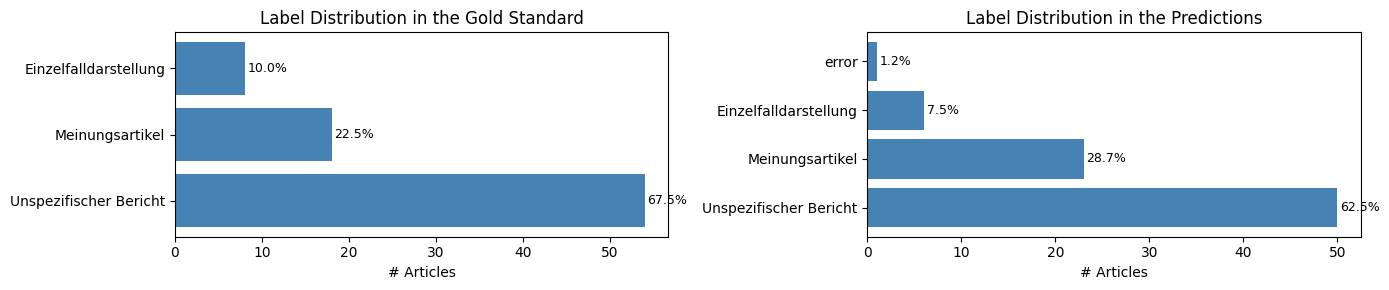

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(3, max(len(label_freq), len(pred_freq)) * 0.6)))

for ax, freq, title in zip(
    axes,
    [label_freq, pred_freq],
    ["Label Distribution in the Gold Standard", "Label Distribution in the Predictions"],
):
    bars = ax.barh(freq["label"], freq["count"], color="steelblue")
    for bar, share in zip(bars, freq["share"]):
        ax.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{share:.1%}",
            va="center",
            fontsize=9,
        )
    ax.set_xlabel("# Articles")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Confusion Matrix
A confusion matrix is a table used to evaluate the performance of a classification model. It compares the model’s predicted labels with the actual (true) labels, showing how many predictions were correct and where the model made mistakes. It provides detailed insight into the counts of true positives, false positives, false negatives, and true negatives, giving a more complete picture of the model’s performance.

For a binary classifier, the matrix has four cells:

|  | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

**How to Read It**
- **Diagonal cells** = correct predictions (should be high)
- **Off-diagonal cells** = errors (should be low)
- **Rows:** indicate the **recall** of a class (how many actual instances were correctly found)
- **Columns:** indicate the **precision** of a class (how many predicted instances were correct)

A confusion matrix gives a **detailed breakdown of model performance**, beyond just overall accuracy. It helps you:

- Identify specific types of errors (e.g., false positives vs. false negatives)
- Understand how well the model performs on each class
- Evaluate metrics like precision, recall, and F1-score
- Detect bias in the model (e.g., favoring one class over another)

This is especially useful in real-world tasks where different errors have different consequences (e.g., medical diagnosis or fraud detection).

In [12]:
# Get true and predicted labels for evaluation
# Use predicted labels for the matrix to ensure that the error class is included
label_list = sorted(eval_df["predicted_label"].unique())
true_labels = eval_df["label"]
predicted_labels = eval_df["predicted_label"]

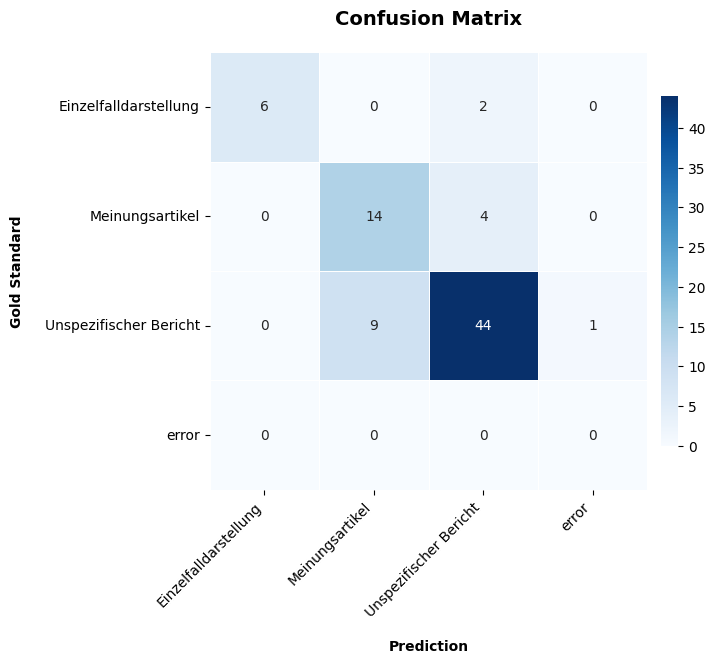

In [15]:
confusion_matrix_df = pd.crosstab(
    true_labels,
    predicted_labels,
    rownames=["Gold Standard"],
    colnames=["Predicted"],
)

# Include the error class in the confusion matrix even if it has zero counts
confusion_matrix_df = confusion_matrix_df.reindex(index=label_list, fill_value=0)

plt.figure(figsize=(9, 7))

# Confusion matrix with absolute counts
sns.heatmap(confusion_matrix_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8, "pad": 0.02})

plt.title("Confusion Matrix", pad=20, fontsize=14, fontweight='bold')
plt.xlabel("Prediction", fontweight='bold', labelpad=15)
plt.ylabel("Gold Standard", fontweight='bold', labelpad=15)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout(pad=2.0)
plt.show()

## Konfusionsmatrix

Die Konfusionsmatrix zeigt, welche Klassen miteinander verwechselt werden:

- **Zeilen** = Gold Standard (was eine Instanz wirklich ist)
- **Spalten** = Prediction des Modells
- **Diagonale** = korrekte Klassifikationen
- **Ausserhalb der Diagonale** = Fehler — welche Klasse wurde mit welcher verwechselt?

Die **normierte Variante** (rechts) zeigt den Recall je Klasse direkt auf der Diagonalen: Welcher Anteil einer Gold-Klasse wurde korrekt erkannt? Alles ausserhalb — inklusive einer `[unbekannt]`-Spalte, falls das Modell halluziniert hat — sind verfehlte Instanzen (False Negatives).

In [14]:
cm_norm = confusion_matrix_df.div(confusion_matrix_df.sum(axis=1), axis=0).fillna(0).round(2)
print(cm_norm.head(10))

Predicted               Einzelfalldarstellung  Meinungsartikel  \
Gold Standard                                                    
Einzelfalldarstellung                    0.75             0.00   
Meinungsartikel                          0.00             0.78   
Unspezifischer Bericht                   0.00             0.17   
error                                    0.00             0.00   

Predicted               Unspezifischer Bericht  error  
Gold Standard                                          
Einzelfalldarstellung                     0.25   0.00  
Meinungsartikel                           0.22   0.00  
Unspezifischer Bericht                    0.81   0.02  
error                                     0.00   0.00  


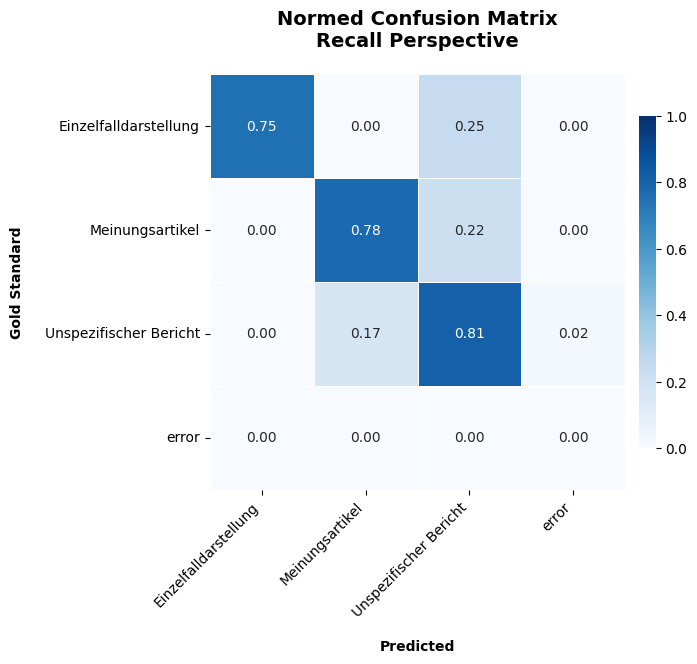

In [ ]:
# Normiert nach Zeilensumme → Diagonale = Recall je Klasse
cm_norm = confusion_matrix_df.div(confusion_matrix_df.sum(axis=1), axis=0).fillna(0).round(2)
#cm_norm_precision = confusion_matrix_df.div(confusion_matrix_df.sum(axis=0), axis=1).fillna(0).round(2)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8, "pad": 0.02})
plt.title("Normed Confusion Matrix\nRecall Perspective", pad=20, fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontweight='bold', labelpad=15)
plt.ylabel("Gold Standard", fontweight='bold', labelpad=15)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout(pad=2.0)
plt.show()

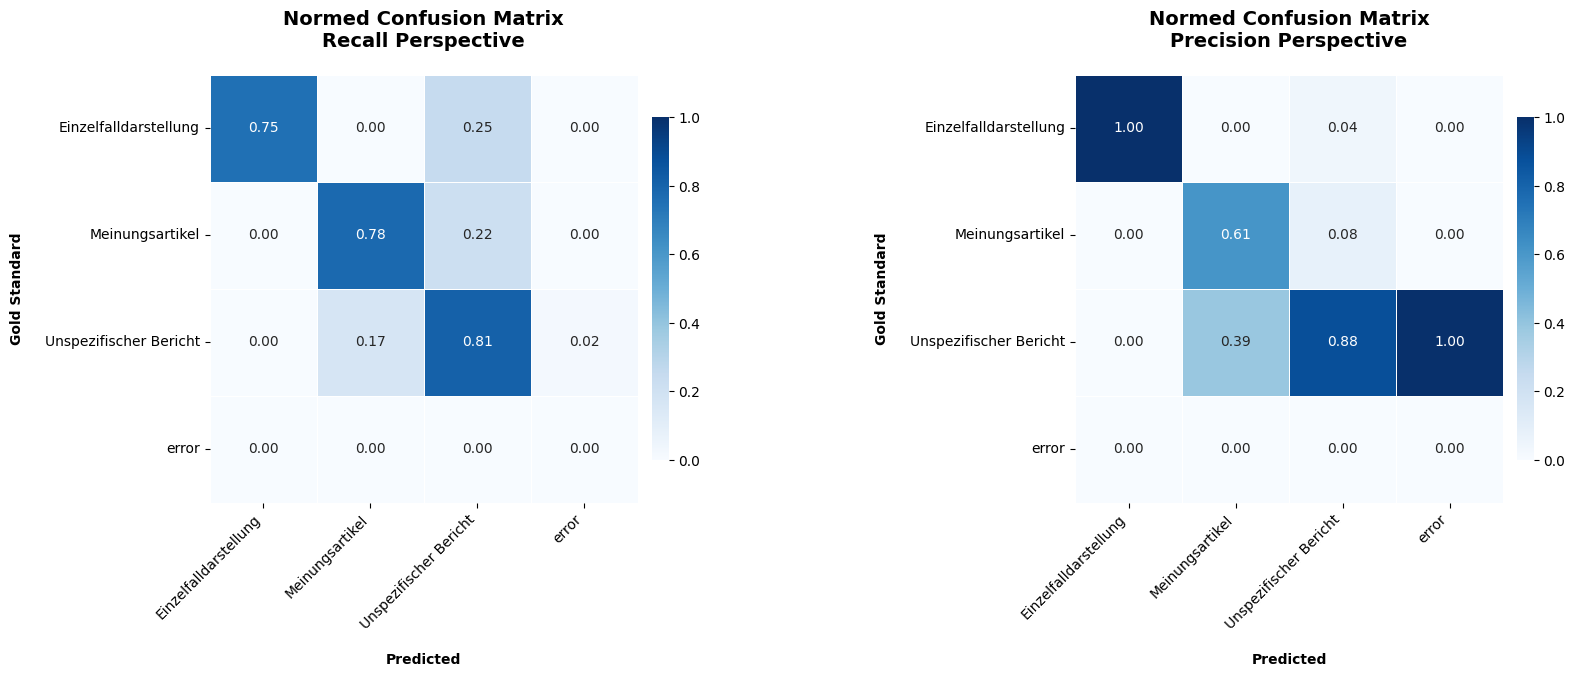

In [19]:
cm_norm_recall = confusion_matrix_df.div(confusion_matrix_df.sum(axis=1), axis=0).fillna(0).round(2)
# Normiert nach Spaltensumme → Diagonale = Precision je Klasse
cm_norm_precision = confusion_matrix_df.div(confusion_matrix_df.sum(axis=0), axis=1).fillna(0).round(2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, cm, title in zip(
    axes,
    [cm_norm_recall, cm_norm_precision],
    ["Normed Confusion Matrix\nRecall Perspective", "Normed Confusion Matrix\nPrecision Perspective"],
):
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                vmin=0, vmax=1, linewidths=0.5, square=True,
                cbar_kws={"shrink": 0.8, "pad": 0.02}, ax=ax)
    ax.set_title(title, pad=20, fontsize=14, fontweight='bold')
    ax.set_xlabel("Predicted", fontweight='bold', labelpad=15)
    ax.set_ylabel("Gold Standard", fontweight='bold', labelpad=15)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout(pad=2.0)
plt.show()


# Normiert nach Zeilensumme → Diagonale = Recall je Klasse
cm_norm_recall = confusion_matrix_df.div(confusion_matrix_df.sum(axis=1), axis=0).fillna(0).round(2)
# Normiert nach Spaltensumme → Diagonale = Precision je Klasse
cm_norm_precision = confusion_matrix_df.div(confusion_matrix_df.sum(axis=0), axis=1).fillna(0).round(2)

# Remove error class: keep only gold labels in both rows and columns
gold_label_list = sorted(eval_df["label"].unique())
cm_norm_recall = cm_norm_recall.loc[
    cm_norm_recall.index.isin(gold_label_list),
    cm_norm_recall.columns.isin(gold_label_list)
]
cm_norm_precision = cm_norm_precision.loc[
    cm_norm_precision.index.isin(gold_label_list),
    cm_norm_precision.columns.isin(gold_label_list)
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, cm, title in zip(
    axes,
    [cm_norm_recall, cm_norm_precision],
    ["Normed Confusion Matrix\nRecall Perspective", "Normed Confusion Matrix\nPrecision Perspective"],
):
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                vmin=0, vmax=1, linewidths=0.5, square=True,
                cbar_kws={"shrink": 0.8, "pad": 0.02}, ax=ax)
    ax.set_title(title, pad=20, fontsize=14, fontweight='bold')
    ax.set_xlabel("Predicted", fontweight='bold', labelpad=15)
    ax.set_ylabel("Gold Standard", fontweight='bold', labelpad=15)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout(pad=2.0)
plt.show()


In [19]:
gold_label_list = sorted(eval_df["label"].unique())
# Pass the label list to sklearn to ensure that all classes (including the error class) are included in the report
report = classification_report(
    true_labels, predicted_labels,
    labels=label_list,
    zero_division=0,
    output_dict=True,
)

print(report)

# Sentinel-Zeile ausblenden — nur Gold-Klassen + Aggregat anzeigen
# Convert true_labels to list
gold_label_list = sorted(eval_df["label"].unique())
display_rows = gold_label_list + ["macro avg", "weighted avg"]
report_df = pd.DataFrame(report).T.loc[display_rows]
print(report_df.round(3).to_string())

accuracy = report['accuracy']
print(f'\nAccuracy : {accuracy:.3f}')

{'Einzelfalldarstellung': {'precision': 1.0, 'recall': 0.75, 'f1-score': 0.8571428571428571, 'support': 8.0}, 'Meinungsartikel': {'precision': 0.6086956521739131, 'recall': 0.7777777777777778, 'f1-score': 0.6829268292682927, 'support': 18.0}, 'Unspezifischer Bericht': {'precision': 0.88, 'recall': 0.8148148148148148, 'f1-score': 0.8461538461538461, 'support': 54.0}, 'error': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}, 'accuracy': 0.8, 'macro avg': {'precision': 0.6221739130434782, 'recall': 0.5856481481481481, 'f1-score': 0.596555883141249, 'support': 80.0}, 'weighted avg': {'precision': 0.8309565217391306, 'recall': 0.8, 'f1-score': 0.8105266684534979, 'support': 80.0}}
                        precision  recall  f1-score  support
Einzelfalldarstellung       1.000   0.750     0.857      8.0
Meinungsartikel             0.609   0.778     0.683     18.0
Unspezifischer Bericht      0.880   0.815     0.846     54.0
macro avg                   0.622   0.586     0.597 

In [18]:
gold_label_list = sorted(eval_df["label"].unique())
# Pass the label list to sklearn to ensure that all classes (including the error class) are included in the report
report = classification_report(
    true_labels, predicted_labels,
    labels=gold_label_list,
    zero_division=0,
    output_dict=True,
)

print(report)

# Sentinel-Zeile ausblenden — nur Gold-Klassen + Aggregat anzeigen
# Convert true_labels to list
gold_label_list = sorted(eval_df["label"].unique())
display_rows = gold_label_list + ["macro avg", "weighted avg"]
report_df = pd.DataFrame(report).T.loc[display_rows]
print(report_df.round(3).to_string())

accuracy = report['accuracy']
print(f'\nAccuracy : {accuracy:.3f}')

{'Einzelfalldarstellung': {'precision': 1.0, 'recall': 0.75, 'f1-score': 0.8571428571428571, 'support': 8.0}, 'Meinungsartikel': {'precision': 0.6086956521739131, 'recall': 0.7777777777777778, 'f1-score': 0.6829268292682927, 'support': 18.0}, 'Unspezifischer Bericht': {'precision': 0.88, 'recall': 0.8148148148148148, 'f1-score': 0.8461538461538461, 'support': 54.0}, 'micro avg': {'precision': 0.810126582278481, 'recall': 0.8, 'f1-score': 0.8050314465408805, 'support': 80.0}, 'macro avg': {'precision': 0.8295652173913043, 'recall': 0.7808641975308642, 'f1-score': 0.795407844188332, 'support': 80.0}, 'weighted avg': {'precision': 0.8309565217391306, 'recall': 0.8, 'f1-score': 0.8105266684534979, 'support': 80.0}}
                        precision  recall  f1-score  support
Einzelfalldarstellung       1.000   0.750     0.857      8.0
Meinungsartikel             0.609   0.778     0.683     18.0
Unspezifischer Bericht      0.880   0.815     0.846     54.0
macro avg                   0.830  

KeyError: 'accuracy'

## Micro-F1 vs. Macro-F1

## Recall bei seltenen Labels

Ein häufiges Missverständnis: ein Modell mit hoher **Accuracy** ist automatisch gut. Das stimmt nicht, sobald die Labels ungleich verteilt sind.

**Gedankenexperiment:** Stell dir vor, 95 % aller Dokumente haben das Label `neutral` und nur 5 % das Label `positiv`. Ein Modell, das *immer* `neutral` vorhersagt, erreicht **95 % Accuracy** — und findet trotzdem kein einziges positives Dokument.

> **Accuracy belohnt das häufige Label. Recall schützt das seltene.**

**Recall** fragt: *Von allen Dokumenten, die wirklich das Label X haben — wie viele hat das Modell gefunden?* Bei seltenen Klassen ist das besonders relevant: genau diese Dokumente sind oft die inhaltlich interessantesten Fälle — und werden am leichtesten übersehen.

Der folgende Code demonstriert diesen Effekt mit den echten Daten aus dem Korpus:

In [ ]:
# Seltenste Klasse im Gold Standard
rarest = label_freq.iloc[-1]
rarest_label = rarest['label']
rarest_count = int(rarest['count'])
rarest_share = rarest['share']

r = report_df.loc[rarest_label]

print(f"Seltenste Klasse: '{rarest_label}'")
print(f'  Anzahl Dokumente: {rarest_count} ({rarest_share:.1%} des Korpus)')
print()
print(f"  Precision : {r['precision']:.3f}")
print(f"  Recall    : {r['recall']:.3f}")
print(f"  F1-Score  : {r['f1-score']:.3f}")
print()
print(f'Gesamt-Accuracy: {accuracy:.3f}')
print()
print('→ Hohe Accuracy kann trotz niedrigem Recall beim seltenen Label auftreten.')
print('→ Macro F1 und Macro Recall gewichten alle Klassen gleichwertig')
print('  und sind daher robustere Metriken bei unausgeglichenen Datensätzen.')

## Inter Annotator Agreement

In [ ]:
kappa = cohen_kappa_score(true_labels, predicted_labels)
print(f"Cohen's κ: {kappa:.3f}")

## Zusammenfassung

In [ ]:
summary = pd.DataFrame({
    'Metrik': ['Accuracy', "Cohen's κ", 'Macro Precision', 'Macro Recall', 'Macro F1'],
    'Wert': [
        accuracy,
        kappa,
        report['macro avg']['precision'],
        report['macro avg']['recall'],
        report['macro avg']['f1-score'],
    ]
})

print(summary.round(3).to_string(index=False))

# Optional: Ergebnisse als CSV speichern
# summary.to_csv(DATA_DIR / f'{CORPUS_NAME}.evaluation_summary.csv', index=False)